Como forma de ganhar tempo para focar em decisões metodológicas mais significativas, LLMs serão empregadas para gerar plots.


OBS: repetições se referem a repetições do KFold

### Leitura das métricas logadas

In [2]:
import os
import sys
import numpy as np
import seaborn as sns
import polars as pl
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
from pprint import pprint
import matplotlib.pyplot as plt
import polars as pl


ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))
from src.constants import NUM_ROUND_DIGITS  # noqa: E402


RESULTS_DIR = Path.cwd().parent / 'results'

In [3]:
# Carregar os dados dos logs do TensorBoard
def load_events_data(log_dir: str):
    ea = event_accumulator.EventAccumulator(log_dir)
    ea.Reload()

    # Acessar os dados de scalars (loss, accuracy, etc.)
    tags = ea.Tags()['scalars']

    # Criar um dataframe vazio para armazenar os dados
    data_train = {}
    data_test = {}
    data_times = {}

    # Iterar sobre as tags e extrair os valores
    for tag in tags:
        if 'step' not in tag and tag != 'epoch':
            # Como estou desconsiderando o métricas a nível de step, 
            # os resultados não precisam de ordenamento ao longo do tempo        
            events = ea.Scalars(tag)
            if 'time' in tag:
                time = events[0].value
                data_times[tag] = time

                continue
                
            for event in events:
                step = event.step  # ignorado, a nível de época
                value = event.value
                if 'train' in tag:
                    if not data_train.get(tag):
                        data_train[tag] = []
                    data_train[tag].append(value)
                elif 'test' in tag:
                    if not data_test.get(tag):
                        data_test[tag] = []
                    data_test[tag].append(value)



    # Mostrar o DataFrame's
    df_train = pl.DataFrame(data_train)
    df_test = pl.DataFrame(data_test)
    data_times = pl.DataFrame(data_times)
    
    return df_train, df_test, data_times

    # # Salvar o DataFrame como CSV (se necessário)
    # df.write_csv(RESULTS_DIR/f"phase_1/csvs/tensorboard_data_polars_{'_'.join(log_dir.split(os.path.sep)[-3:])}.csv")
    # print(df)

In [4]:
#          model | repet | kfolditer | metric x | metric y | ...
#                                       value1  |  value1  | ...
#                                       value2  |  value2  | ...
#                                       value3  |  value3  | ...
#                                       value4  |  value4  | ...
#                                       value5  |  value5  | ...
df_list_train = []
df_list_test = []
df_list_times = []


for events_dir in RESULTS_DIR.glob('tb_logs/*/kfolditer*'):
    # repet = int(events_dir.parents[0].name[-1])  #TODO: se houvesse repetiçõe do kfold
    model = events_dir.parent.name
    kfolditer = int(events_dir.name[-1])

    # carrega os datos de uma iteração do kfold
    df_train, df_test, df_times = load_events_data(str(events_dir))

    # Organização dos dados
    # treino
    df_train = df_train.with_columns([
        pl.lit(model).alias('model'),
        # pl.lit(repet).alias('repet'),
        pl.lit(kfolditer).alias('kfolditer'),
    ])

    # teste
    df_test = df_test.with_columns([
        pl.lit(model).alias('model'),
        # pl.lit(repet).alias('repet'),
        pl.lit(kfolditer).alias('kfolditer'),
    ])

    # times
    df_times = df_times.with_columns([
        pl.lit(model).alias('model'),
        # pl.lit(repet).alias('repet'),
        pl.lit(kfolditer).alias('kfolditer'),
    ])


    df_list_train.append(df_train)
    df_list_test.append(df_test)
    df_list_times.append(df_times)


df_train: pl.DataFrame = pl.concat(df_list_train)
df_test: pl.DataFrame = pl.concat(df_list_test)
df_times: pl.DataFrame = pl.concat(df_list_times)

In [5]:
(RESULTS_DIR/"csvs").mkdir(parents=True, exist_ok=True)

df_train.write_csv(RESULTS_DIR / 'csvs/train_epoch_results.csv')
df_test.write_csv(RESULTS_DIR / 'csvs/test_epoch_results.csv')
df_times.write_csv(RESULTS_DIR / 'csvs/times_results.csv')

### Distribuição

In [6]:
df_test

epoch_test_per_image_sensitivity,epoch_test_dataset_sensitivity,epoch_test_per_image_precision,epoch_test_dataset_precision,epoch_test_per_image_f1,epoch_test_dataset_f1,epoch_test_per_image_iou_right,epoch_test_dataset_iou_right,epoch_test_per_image_sensitivity_right,epoch_test_dataset_sensitivity_right,epoch_test_per_image_precision_right,epoch_test_dataset_precision_right,epoch_test_per_image_f1_right,epoch_test_dataset_f1_right,epoch_test_per_image_iou_left,epoch_test_dataset_iou_left,epoch_test_per_image_sensitivity_left,epoch_test_dataset_sensitivity_left,epoch_test_per_image_precision_left,epoch_test_dataset_precision_left,epoch_test_per_image_f1_left,epoch_test_dataset_f1_left,epoch_test_lung_micro_imagewise_iou,epoch_test_lung_micro_f1,epoch_test_lung_micro_imagewise_f1,epoch_test_per_patient_iou_std,epoch_test_per_patient_f1_mean,epoch_test_per_patient_f1_std,epoch_test_per_patient_iou_mean,epoch_test_dataset_iou,epoch_test_per_image_iou,epoch_test_lung_micro_iou,epoch_avg_loss_test,model,kfolditer
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32
0.244655,0.807477,0.254854,0.937649,0.246422,0.867511,0.239865,0.772995,0.248843,0.822903,0.255193,0.927249,0.248963,0.871965,0.234159,0.759103,0.240467,0.79205,0.254514,0.948049,0.243881,0.863057,0.795317,0.917382,0.82318,0.197284,0.893653,0.178743,0.839623,0.766049,0.237012,0.847374,0.088016,"""deeplabv3+_256x256_pngs_prepro…",0
0.244145,0.96992,0.25158,0.981408,0.246276,0.975628,0.239342,0.953568,0.246111,0.971888,0.251908,0.980616,0.247843,0.976232,0.236365,0.951266,0.24218,0.967952,0.251252,0.982201,0.244708,0.975025,0.746418,0.98132,0.772909,0.075858,0.957892,0.046271,0.923073,0.952417,0.237854,0.963326,0.040091,"""deeplabv3+_256x256_pngs_prepro…",1
0.234473,0.973748,0.233948,0.964912,0.233009,0.969269,0.22377,0.941731,0.231969,0.968067,0.232688,0.971923,0.231265,0.969991,0.227183,0.93901,0.236976,0.97943,0.235208,0.957901,0.234753,0.968546,0.728237,0.982909,0.753087,0.06092,0.958241,0.035101,0.921952,0.940371,0.225476,0.966393,0.048067,"""deeplabv3+_256x256_pngs_prepro…",2
0.231109,0.951692,0.236917,0.96359,0.231583,0.957508,0.229437,0.921088,0.240187,0.962582,0.241718,0.955292,0.238924,0.958923,0.216239,0.915879,0.222032,0.940802,0.232117,0.971889,0.224242,0.956093,0.767391,0.978667,0.796397,0.04714,0.954499,0.026038,0.914282,0.918483,0.222838,0.958224,0.06219,"""deeplabv3+_256x256_pngs_prepro…",3
0.240602,0.953989,0.243537,0.957278,0.240275,0.955582,0.233105,0.915903,0.242444,0.961275,0.242976,0.950991,0.240965,0.956106,0.232245,0.913983,0.23876,0.946702,0.244099,0.963565,0.239585,0.955059,0.7707,0.98296,0.796796,0.116537,0.931108,0.079601,0.882516,0.914943,0.232675,0.966491,0.061947,"""deeplabv3+_256x256_pngs_prepro…",4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.220251,0.868149,0.220271,0.870495,0.218305,0.869291,0.214126,0.772788,0.223538,0.875685,0.223435,0.868016,0.221302,0.871834,0.20864,0.764834,0.216964,0.860612,0.217106,0.872974,0.215308,0.866749,0.755368,0.981971,0.779032,0.219875,0.878899,0.212373,0.825424,0.768811,0.211383,0.96458,0.1414,"""unet++_256x256_pngs_preproc""",5
0.226004,0.89535,0.233571,0.909161,0.226325,0.902156,0.218142,0.829621,0.226773,0.906451,0.235684,0.907305,0.227772,0.906878,0.215641,0.81395,0.225236,0.88425,0.231459,0.911017,0.224878,0.897434,0.786681,0.982621,0.812153,0.258198,0.822812,0.238938,0.7502,0.821786,0.216891,0.965836,0.110104,"""unet++_256x256_pngs_preproc""",6
0.220571,0.87223,0.220456,0.876768,0.219369,0.874205,0.21368,0.78716,0.221445,0.894684,0.219015,0.867546,0.219066,0.880906,0.21433,0.766012,0.219697,0.849775,0.221897,0.885989,0.219671,0.867505,0.780777,0.986983,0.800153,0.317794,0.842915,0.319495,0.816111,0.776586,0.214005,0.974301,0.12999,"""unet++_256x256_pngs_preproc""",7


### Médias Gerais


In [7]:
df_test

epoch_test_per_image_sensitivity,epoch_test_dataset_sensitivity,epoch_test_per_image_precision,epoch_test_dataset_precision,epoch_test_per_image_f1,epoch_test_dataset_f1,epoch_test_per_image_iou_right,epoch_test_dataset_iou_right,epoch_test_per_image_sensitivity_right,epoch_test_dataset_sensitivity_right,epoch_test_per_image_precision_right,epoch_test_dataset_precision_right,epoch_test_per_image_f1_right,epoch_test_dataset_f1_right,epoch_test_per_image_iou_left,epoch_test_dataset_iou_left,epoch_test_per_image_sensitivity_left,epoch_test_dataset_sensitivity_left,epoch_test_per_image_precision_left,epoch_test_dataset_precision_left,epoch_test_per_image_f1_left,epoch_test_dataset_f1_left,epoch_test_lung_micro_imagewise_iou,epoch_test_lung_micro_f1,epoch_test_lung_micro_imagewise_f1,epoch_test_per_patient_iou_std,epoch_test_per_patient_f1_mean,epoch_test_per_patient_f1_std,epoch_test_per_patient_iou_mean,epoch_test_dataset_iou,epoch_test_per_image_iou,epoch_test_lung_micro_iou,epoch_avg_loss_test,model,kfolditer
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32
0.244655,0.807477,0.254854,0.937649,0.246422,0.867511,0.239865,0.772995,0.248843,0.822903,0.255193,0.927249,0.248963,0.871965,0.234159,0.759103,0.240467,0.79205,0.254514,0.948049,0.243881,0.863057,0.795317,0.917382,0.82318,0.197284,0.893653,0.178743,0.839623,0.766049,0.237012,0.847374,0.088016,"""deeplabv3+_256x256_pngs_prepro…",0
0.244145,0.96992,0.25158,0.981408,0.246276,0.975628,0.239342,0.953568,0.246111,0.971888,0.251908,0.980616,0.247843,0.976232,0.236365,0.951266,0.24218,0.967952,0.251252,0.982201,0.244708,0.975025,0.746418,0.98132,0.772909,0.075858,0.957892,0.046271,0.923073,0.952417,0.237854,0.963326,0.040091,"""deeplabv3+_256x256_pngs_prepro…",1
0.234473,0.973748,0.233948,0.964912,0.233009,0.969269,0.22377,0.941731,0.231969,0.968067,0.232688,0.971923,0.231265,0.969991,0.227183,0.93901,0.236976,0.97943,0.235208,0.957901,0.234753,0.968546,0.728237,0.982909,0.753087,0.06092,0.958241,0.035101,0.921952,0.940371,0.225476,0.966393,0.048067,"""deeplabv3+_256x256_pngs_prepro…",2
0.231109,0.951692,0.236917,0.96359,0.231583,0.957508,0.229437,0.921088,0.240187,0.962582,0.241718,0.955292,0.238924,0.958923,0.216239,0.915879,0.222032,0.940802,0.232117,0.971889,0.224242,0.956093,0.767391,0.978667,0.796397,0.04714,0.954499,0.026038,0.914282,0.918483,0.222838,0.958224,0.06219,"""deeplabv3+_256x256_pngs_prepro…",3
0.240602,0.953989,0.243537,0.957278,0.240275,0.955582,0.233105,0.915903,0.242444,0.961275,0.242976,0.950991,0.240965,0.956106,0.232245,0.913983,0.23876,0.946702,0.244099,0.963565,0.239585,0.955059,0.7707,0.98296,0.796796,0.116537,0.931108,0.079601,0.882516,0.914943,0.232675,0.966491,0.061947,"""deeplabv3+_256x256_pngs_prepro…",4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.220251,0.868149,0.220271,0.870495,0.218305,0.869291,0.214126,0.772788,0.223538,0.875685,0.223435,0.868016,0.221302,0.871834,0.20864,0.764834,0.216964,0.860612,0.217106,0.872974,0.215308,0.866749,0.755368,0.981971,0.779032,0.219875,0.878899,0.212373,0.825424,0.768811,0.211383,0.96458,0.1414,"""unet++_256x256_pngs_preproc""",5
0.226004,0.89535,0.233571,0.909161,0.226325,0.902156,0.218142,0.829621,0.226773,0.906451,0.235684,0.907305,0.227772,0.906878,0.215641,0.81395,0.225236,0.88425,0.231459,0.911017,0.224878,0.897434,0.786681,0.982621,0.812153,0.258198,0.822812,0.238938,0.7502,0.821786,0.216891,0.965836,0.110104,"""unet++_256x256_pngs_preproc""",6
0.220571,0.87223,0.220456,0.876768,0.219369,0.874205,0.21368,0.78716,0.221445,0.894684,0.219015,0.867546,0.219066,0.880906,0.21433,0.766012,0.219697,0.849775,0.221897,0.885989,0.219671,0.867505,0.780777,0.986983,0.800153,0.317794,0.842915,0.319495,0.816111,0.776586,0.214005,0.974301,0.12999,"""unet++_256x256_pngs_preproc""",7


In [8]:
# treino
geral_mean_df = (
    df_test.group_by('model')
    .agg([pl.col(c).mean() for c in df_test.columns if 'epoch' in c])
)

In [10]:
geral_mean_df

model,epoch_test_per_image_sensitivity,epoch_test_dataset_sensitivity,epoch_test_per_image_precision,epoch_test_dataset_precision,epoch_test_per_image_f1,epoch_test_dataset_f1,epoch_test_per_image_iou_right,epoch_test_dataset_iou_right,epoch_test_per_image_sensitivity_right,epoch_test_dataset_sensitivity_right,epoch_test_per_image_precision_right,epoch_test_dataset_precision_right,epoch_test_per_image_f1_right,epoch_test_dataset_f1_right,epoch_test_per_image_iou_left,epoch_test_dataset_iou_left,epoch_test_per_image_sensitivity_left,epoch_test_dataset_sensitivity_left,epoch_test_per_image_precision_left,epoch_test_dataset_precision_left,epoch_test_per_image_f1_left,epoch_test_dataset_f1_left,epoch_test_lung_micro_imagewise_iou,epoch_test_lung_micro_f1,epoch_test_lung_micro_imagewise_f1,epoch_test_per_patient_iou_std,epoch_test_per_patient_f1_mean,epoch_test_per_patient_f1_std,epoch_test_per_patient_iou_mean,epoch_test_dataset_iou,epoch_test_per_image_iou,epoch_test_lung_micro_iou,epoch_avg_loss_test
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""unet++_256x256_pngs_preproc""",0.22463,0.890297,0.226183,0.906905,0.222196,0.89618,0.212912,0.817118,0.221899,0.877523,0.225926,0.918918,0.220652,0.895538,0.214752,0.817697,0.22736,0.903072,0.22644,0.894891,0.223739,0.896823,0.769329,0.976574,0.793115,0.192226,0.865353,0.166474,0.807804,0.817407,0.213832,0.954876,0.11168
"""deeplabv3+_256x256_pngs_prepro…",0.23535,0.91913,0.240986,0.94075,0.236139,0.929295,0.228012,0.873996,0.23637,0.922092,0.240824,0.939676,0.236602,0.930417,0.227116,0.869747,0.234331,0.916169,0.241147,0.941824,0.235675,0.928173,0.757426,0.973295,0.784723,0.136236,0.922247,0.109831,0.876568,0.871872,0.227564,0.948625,0.076063
"""segformer_256x256_pngs_preproc""",0.227346,0.89683,0.231355,0.909718,0.226924,0.902771,0.218356,0.832707,0.228117,0.900196,0.231929,0.912129,0.227507,0.905557,0.217495,0.824129,0.226575,0.893464,0.230781,0.907307,0.226342,0.899985,0.754852,0.972524,0.782688,0.200449,0.883491,0.174184,0.835593,0.828418,0.217926,0.947173,0.100225
"""dpt_256x256_pngs_preproc""",0.239085,0.926631,0.243668,0.945851,0.239263,0.935559,0.231253,0.884029,0.240661,0.931303,0.244068,0.943984,0.2403,0.937069,0.229133,0.878504,0.23751,0.921959,0.243267,0.947718,0.238227,0.934049,0.760164,0.972732,0.787594,0.139152,0.924338,0.109178,0.878434,0.881267,0.230193,0.947588,0.073815


C:\Users\Felipe\AppData\Local\Temp\ipykernel_19372\1403074483.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(geral_mean_df["model"], rotation=45, ha="right")
C:\Users\Felipe\AppData\Local\Temp\ipykernel_19372\1403074483.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(geral_mean_df["model"], rotation=45, ha="right")
C:\Users\Felipe\AppData\Local\Temp\ipykernel_19372\1403074483.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(geral_mean_df["model"], rotation=45, ha="right")


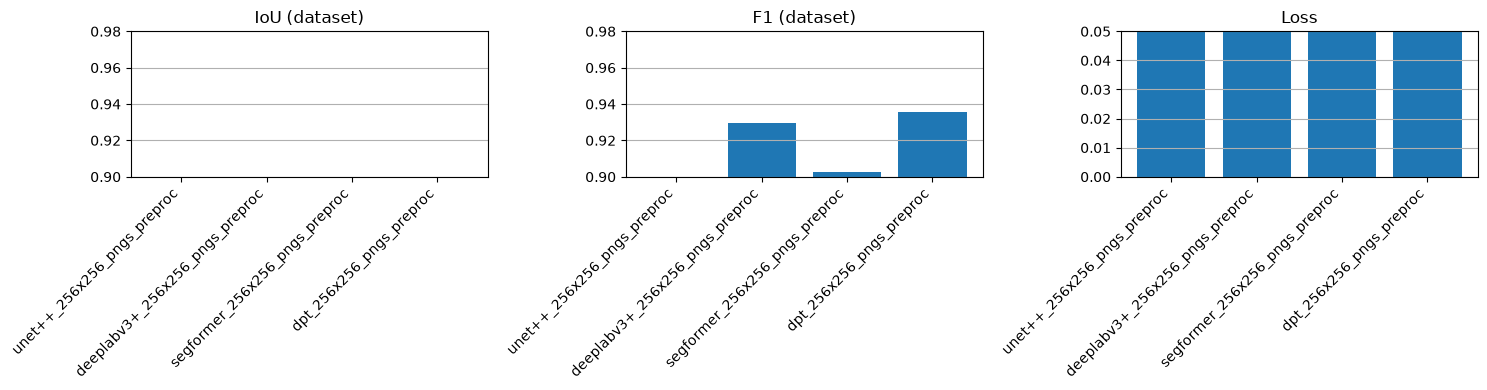

In [11]:
metrics = {
    "IoU (dataset)": "epoch_test_dataset_iou",
    "F1 (dataset)": "epoch_test_dataset_f1",
    "Loss": "epoch_avg_loss_test",
}

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, col) in zip(axs, metrics.items()):
    ax.set_ylim(0.90, 0.98)
    if title=='Loss':
        ax.set_ylim(0, 0.05)

    ax.bar(geral_mean_df["model"], geral_mean_df[col])
    ax.set_title(title)
    ax.set_xticklabels(geral_mean_df["model"], rotation=45, ha="right")
    ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

### Tempo de treinamento e teste

In [12]:
df_times_agrupado = (
    df_times
    .group_by('model')
    .agg([
        (pl.col('training_time')/60).mean().round(NUM_ROUND_DIGITS).alias('mean_training_time'),
        (pl.col('training_time')/60).std().round(NUM_ROUND_DIGITS).alias('std_training_time'),

        pl.col('test_time').mean().round(NUM_ROUND_DIGITS).alias('mean_test_time'),
        pl.col('test_time').std().round(NUM_ROUND_DIGITS).alias('std_test_time'),
    ])

)

df_times_agrupado.write_csv(RESULTS_DIR/f'{PHASE}/csvs/train_and_test_time.csv')

NameError: name 'PHASE' is not defined

In [13]:
# Paleta
df_models_fmt = df_times_agrupado.map_columns('model', lambda c: c.map_elements(lambda e: e.split('_')[0]))  # apenas ajustando o nome dos modelos
unique_models = ['dpt', 'deeplabv3+', 'unet++', 'segformer']
palette_dict = {model: color for model, color in zip(unique_models, sns.color_palette("Set2", n_colors=len(unique_models)))}

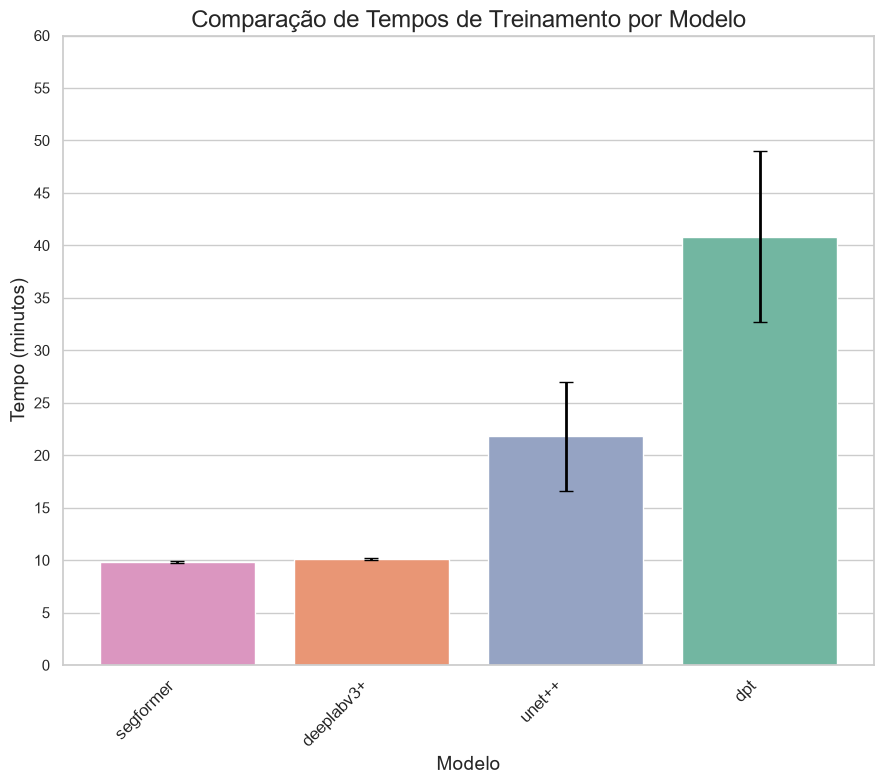

NameError: name 'PHASE' is not defined

In [14]:
# Criando o gráfico
df = df_models_fmt.sort('mean_training_time')
fig = plt.figure(figsize=(9, 8))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras com seaborn
ax = sns.barplot(x='model', 
                 y='mean_training_time', 
                 hue='model', 
                 data=df, 
                 palette=palette_dict, 
                 errorbar=None)  # Desabilitando o intervalo de confiança padrão

# Adicionando as barras de erro manualmente com ax.errorbar
ax.errorbar(x=range(len(df['model'])),
            y=df['mean_training_time'],
            yerr=df['std_training_time'],
            fmt='none',  # Sem marcação, apenas as barras de erro
            color='black',  # Cor das barras de erro
            capsize=5,  # Capacidade das barras de erro
            elinewidth=2,  # Largura das barras de erro
            errorevery=1,  # Mostra uma barra de erro para cada ponto
            label="Desvio Padrão")

# Adicionando título e rótulos
plt.title('Comparação de Tempos de Treinamento por Modelo', fontsize=17)
plt.xlabel('Modelo', fontsize=14)
plt.ylabel('Tempo (minutos)', fontsize=14)

# Ajustando o gráfico para melhorar a visualização
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(ticks=list(range(0, 61, 5)))
plt.tight_layout()

# Exibindo o gráfico
plt.show()

#Salvando
fig.savefig(RESULTS_DIR/f"{PHASE}/figs/train_time.png", dpi=250)


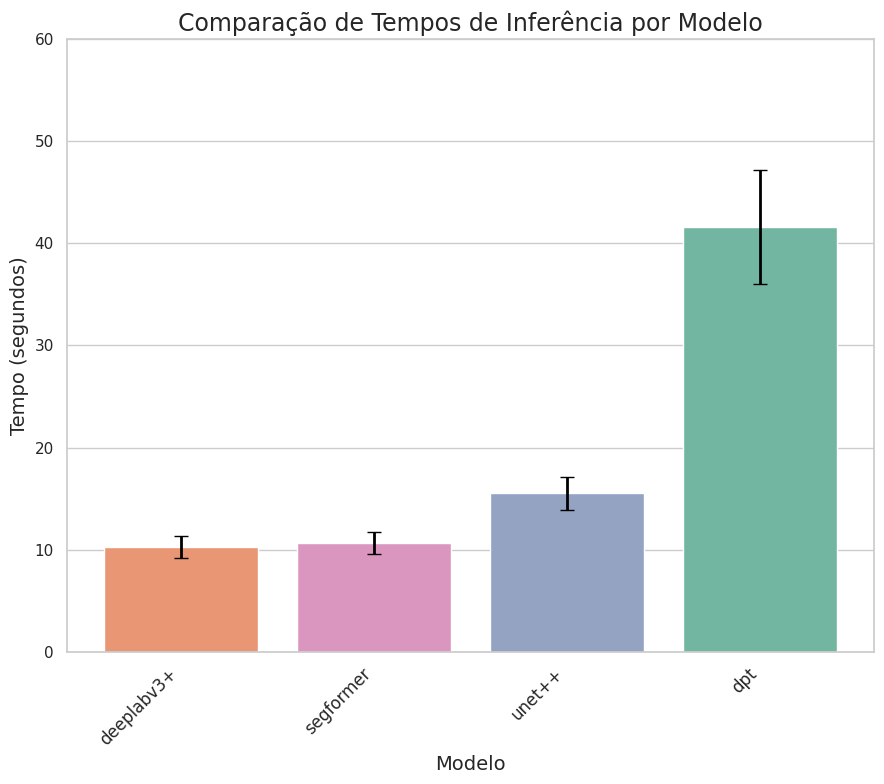

In [29]:
# Criando o gráfico
df = df_models_fmt.sort('mean_test_time')
fig = plt.figure(figsize=(9, 8))
sns.set_theme(style="whitegrid")

# Criando o gráfico de barras com seaborn
ax = sns.barplot(x='model', 
                 y='mean_test_time', 
                 hue='model', 
                 data=df, 
                 palette=palette_dict, 
                 errorbar=None)  # Desabilitando o intervalo de confiança padrão

# Adicionando as barras de erro manualmente com ax.errorbar
ax.errorbar(x=range(len(df['model'])),
            y=df['mean_test_time'],
            yerr=df['std_test_time'],
            fmt='none',  # Sem marcação, apenas as barras de erro
            color='black',  # Cor das barras de erro
            capsize=5,  # Capacidade das barras de erro
            elinewidth=2,  # Largura das barras de erro
            errorevery=1,  # Mostra uma barra de erro para cada ponto
            label="Desvio Padrão")

# Adicionando título e rótulos
plt.title('Comparação de Tempos de Inferência por Modelo', fontsize=17)
plt.xlabel('Modelo', fontsize=14)
plt.ylabel('Tempo (segundos)', fontsize=14)

# Ajustando o gráfico para melhorar a visualização
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(ticks=list(range(0, 61, 10)))
plt.tight_layout()

# Exibindo o gráfico
plt.show()

# Salvando
fig.savefig(RESULTS_DIR/f"{PHASE}/figs/test_time.png", dpi=250)


### Mediana

/tmp/ipykernel_2013292/844988596.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(geral_median_df["model"], rotation=45, ha="right")
/tmp/ipykernel_2013292/844988596.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(geral_median_df["model"], rotation=45, ha="right")
/tmp/ipykernel_2013292/844988596.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(geral_median_df["model"], rotation=45, ha="right")


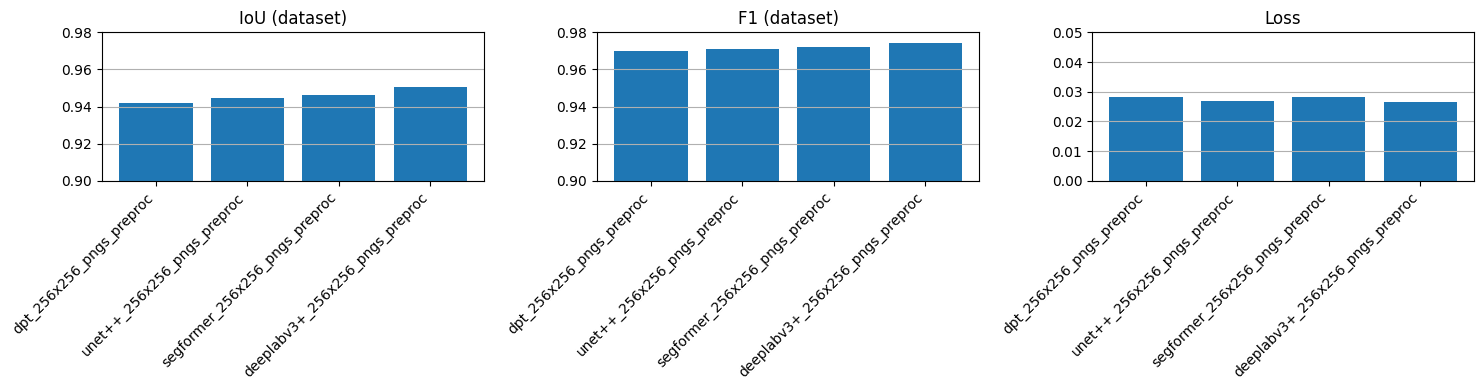

In [134]:
# treino
geral_median_df = (
    df_test.group_by('model')
    .agg([pl.col(c).median() for c in df_test.columns if 'epoch' in c])
)


metrics = {
    "IoU (dataset)": "epoch_test_dataset_iou",
    "F1 (dataset)": "epoch_test_dataset_f1",
    "Loss": "epoch_avg_loss_test",
}

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, col) in zip(axs, metrics.items()):
    ax.set_ylim(0.90, 0.98)
    if title=='Loss':
        ax.set_ylim(0, 0.05)

    ax.bar(geral_median_df["model"], geral_median_df[col])
    ax.set_title(title)
    ax.set_xticklabels(geral_median_df["model"], rotation=45, ha="right")
    ax.grid(True, axis="y")

plt.tight_layout()
plt.show()

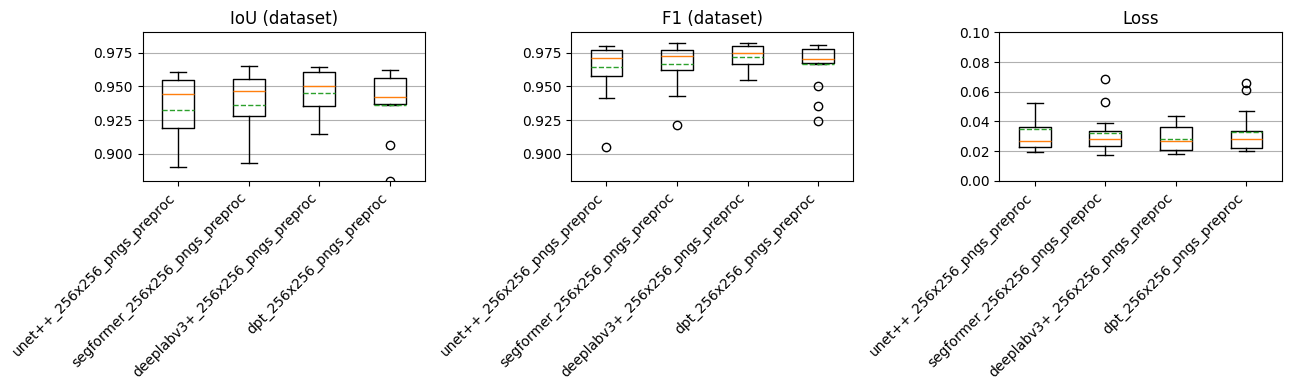

In [135]:
import matplotlib.pyplot as plt
import polars as pl

metrics = {
    "IoU (dataset)": "epoch_test_dataset_iou",
    "F1 (dataset)": "epoch_test_dataset_f1",
    "Loss": "epoch_avg_loss_test",
}

models = df_test["model"].unique().to_list()

fig, axs = plt.subplots(1, 3, figsize=(13, 4), dpi=100)

for ax, (title, col) in zip(axs, metrics.items()):
    data = [
        df_test.filter(pl.col("model") == m)[col].to_numpy()
        for m in models
    ]

    ax.boxplot(
        data,
        showmeans=True,
        meanline=True
    )

    ax.set_title(title)
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(models, rotation=45, ha="right")
    ax.grid(True, axis="y")

    if title == "Loss":
        ax.set_ylim(0, 0.10)
    else:
        ax.set_ylim(0.88, 0.99)

plt.tight_layout()
plt.show()


### BoxPlots

In [13]:
box_plot_cols = [col for col in df_test.columns if 'image' not in col]

In [14]:
df = df_test.map_columns('model', lambda c: c.map_elements(lambda e: e.split('_')[0]))  # apenas ajustando o nome dos modelos

In [15]:
box_plot_cols

['epoch_test_dataset_iou',
 'epoch_test_dataset_sensitivity',
 'epoch_test_dataset_specificity',
 'epoch_test_dataset_f1',
 'epoch_avg_loss_test',
 'model',
 'repet',
 'kfolditer']

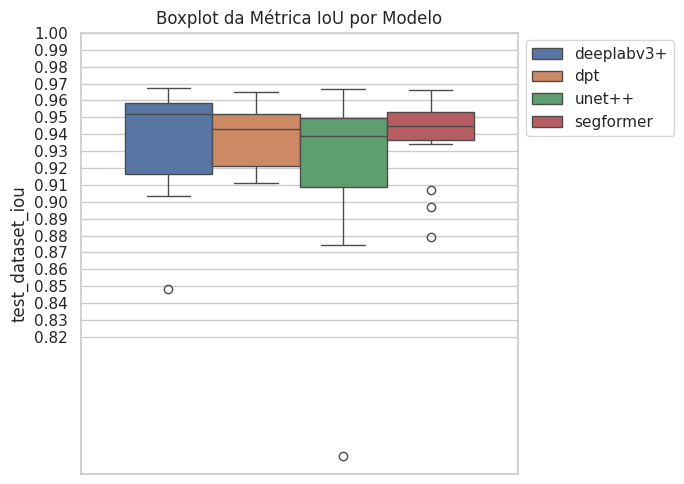

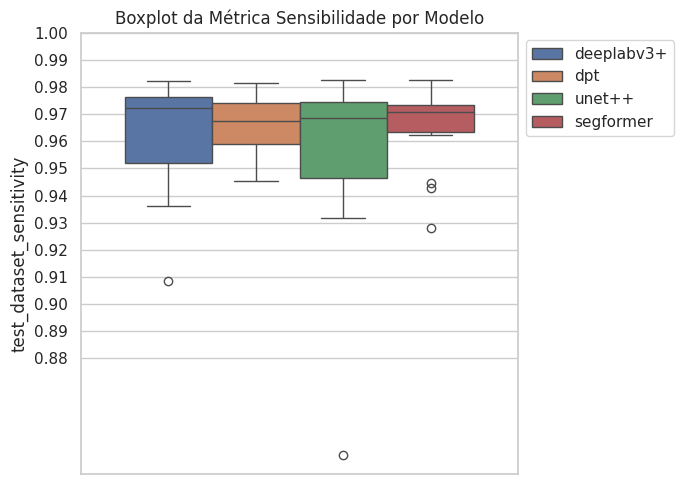

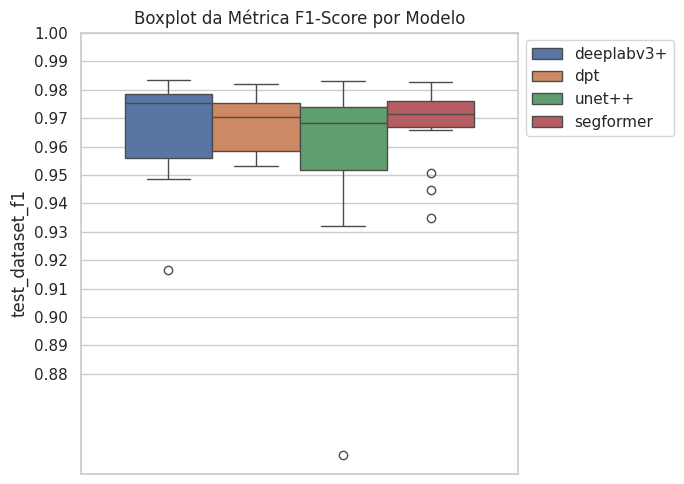

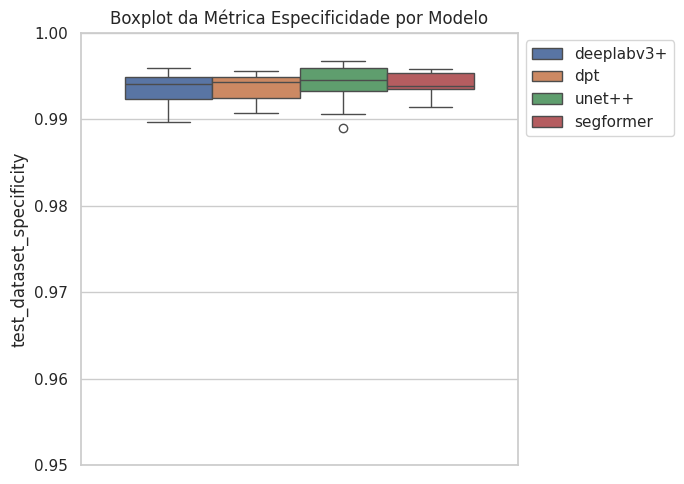

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns


# Criando o boxplot
plt.figure(figsize=(7, 5), dpi=100)
sns.boxplot(y='epoch_test_dataset_iou', hue='model', data=df)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.ylabel('test_dataset_iou')

# Ajustando o gráfico
plt.yticks(np.arange(0.82, 1.001, 0.01))
plt.title("Boxplot da Métrica IoU por Modelo")
plt.tight_layout()
plt.show()


# Criando o boxplot
plt.figure(figsize=(7, 5), dpi=100)
sns.boxplot(y='epoch_test_dataset_sensitivity', hue='model', data=df)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.ylabel('test_dataset_sensitivity')

# Ajustando o gráfico
plt.yticks(np.arange(0.88, 1.001, 0.01))
plt.title("Boxplot da Métrica Sensibilidade por Modelo")
plt.tight_layout()
plt.show()


# Criando o boxplot
plt.figure(figsize=(7, 5), dpi=100)
sns.boxplot(y='epoch_test_dataset_f1', hue='model', data=df)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.ylabel('test_dataset_f1')

# Ajustando o gráfico
plt.yticks(np.arange(0.88, 1.001, 0.01))
plt.title("Boxplot da Métrica F1-Score por Modelo")
plt.tight_layout()
plt.show()


# Criando o boxplot
plt.figure(figsize=(7, 5), dpi=100)
sns.boxplot(y='epoch_test_dataset_specificity', hue='model', data=df)
plt.legend(loc='best', bbox_to_anchor=(1, 1))
plt.ylabel('test_dataset_specificity')

# Ajustando o gráfico
plt.yticks(np.arange(0.95, 1.001, 0.01))
plt.title("Boxplot da Métrica Especificidade por Modelo")
plt.tight_layout()
plt.show()




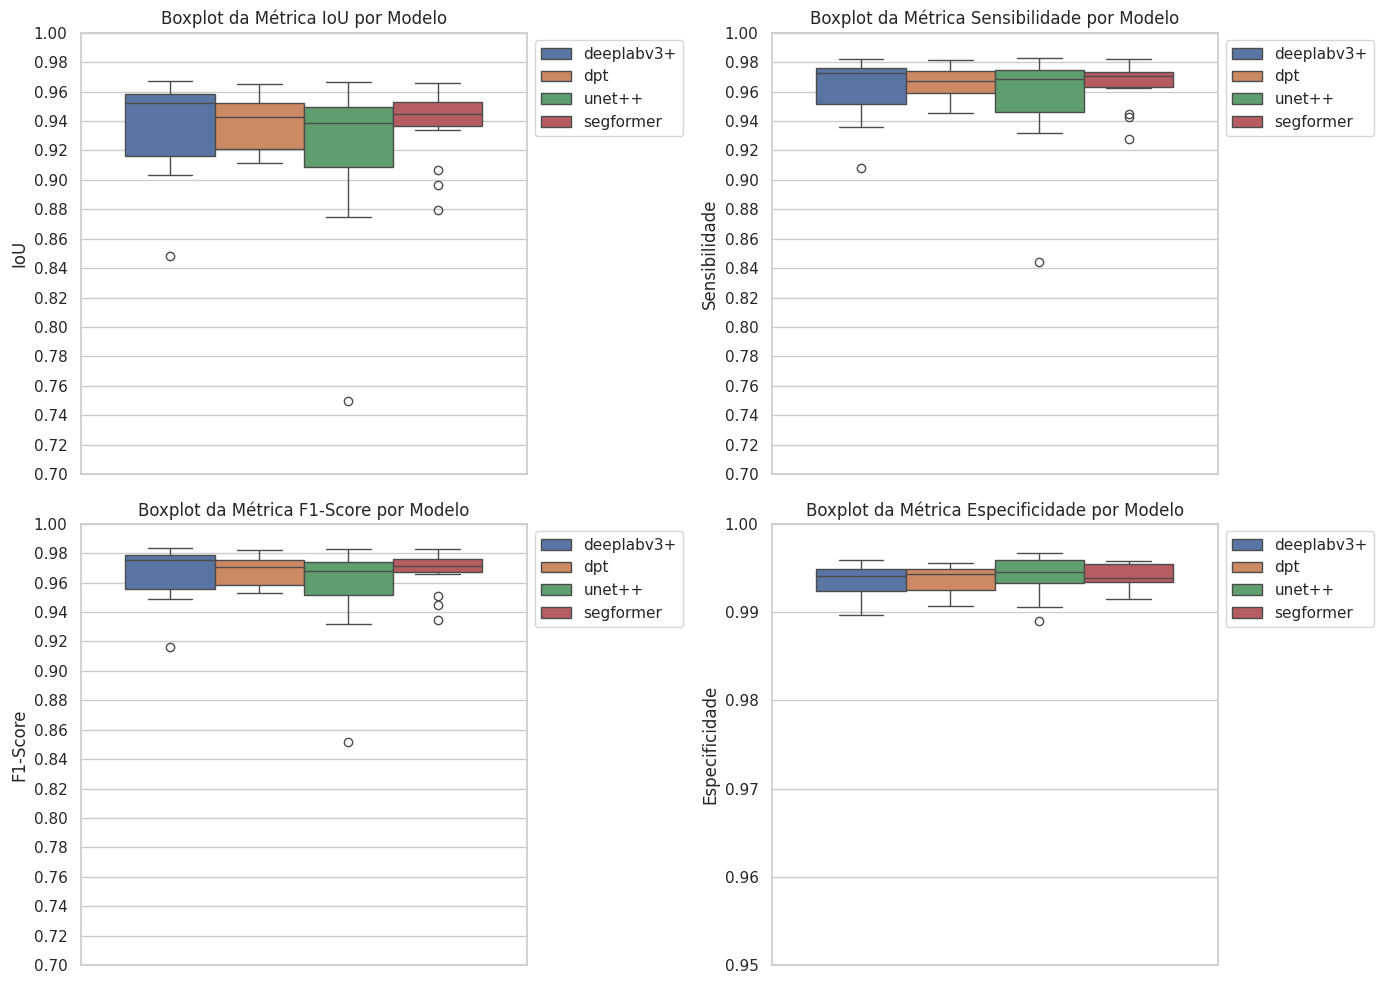

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Criando uma figura com subfiguras
fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=100)

# Boxplot 1 - IoU
sns.boxplot(ax=axs[0, 0], y='epoch_test_dataset_iou', hue='model', data=df)
axs[0, 0].legend(loc='best', bbox_to_anchor=(1, 1))
axs[0, 0].set_ylabel('IoU')
axs[0, 0].set_title("Boxplot da Métrica IoU por Modelo")
axs[0, 0].set_yticks(np.arange(0.70, 1.001, 0.02))

# Boxplot 2 - Sensibilidade
sns.boxplot(ax=axs[0, 1], y='epoch_test_dataset_sensitivity', hue='model', data=df)
axs[0, 1].legend(loc='best', bbox_to_anchor=(1, 1))
axs[0, 1].set_ylabel('Sensibilidade')
axs[0, 1].set_title("Boxplot da Métrica Sensibilidade por Modelo")
axs[0, 1].set_yticks(np.arange(0.70, 1.001, 0.02))

# Boxplot 3 - F1-Score
sns.boxplot(ax=axs[1, 0], y='epoch_test_dataset_f1', hue='model', data=df)
axs[1, 0].legend(loc='best', bbox_to_anchor=(1, 1))
axs[1, 0].set_ylabel('F1-Score')
axs[1, 0].set_title("Boxplot da Métrica F1-Score por Modelo")
axs[1, 0].set_yticks(np.arange(0.70, 1.001, 0.02))

# Boxplot 4 - Especificidade
sns.boxplot(ax=axs[1, 1], y='epoch_test_dataset_specificity', hue='model', data=df)
axs[1, 1].legend(loc='best', bbox_to_anchor=(1, 1))
axs[1, 1].set_ylabel('Especificidade')
axs[1, 1].set_title("Boxplot da Métrica Especificidade por Modelo")
axs[1, 1].set_yticks(np.arange(0.95, 1.001, 0.01))

# Ajustando layout e exibição
plt.tight_layout()
plt.show()


### Testes estatísticos

In [30]:
dados_teste_agrupados = (  # O propósito aqui é obter todas os resultados para cada modelo
    df_test
    .group_by('model')
    .agg([pl.col(c) for c in df_test.columns if 'epoch' in c])
)

In [19]:
dados_teste_agrupados

model,epoch_test_per_image_iou,epoch_test_dataset_iou,epoch_test_per_image_sensitivity,epoch_test_dataset_sensitivity,epoch_test_per_image_specificity,epoch_test_dataset_specificity,epoch_test_per_image_f1,epoch_test_dataset_f1,epoch_avg_loss_test
str,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64]
"""deeplabv3+_256x256_pngs_prepro…","[0.309694, 0.301453, … 0.307112]","[0.965577, 0.903507, … 0.952757]","[0.318888, 0.307676, … 0.313233]","[0.982228, 0.936242, … 0.969822]","[0.329903, 0.327702, … 0.32864]","[0.995935, 0.989664, … 0.993116]","[0.314988, 0.308944, … 0.313597]","[0.982422, 0.94872, … 0.975681]","[0.016321, 0.04277, … 0.023069]"
"""segformer_256x256_pngs_preproc""","[0.305005, 0.30462, … 0.305077]","[0.934207, 0.953567, … 0.952606]","[0.312753, 0.310255, … 0.316052]","[0.962486, 0.970636, … 0.976639]","[0.329304, 0.328534, … 0.330029]","[0.992966, 0.994104, … 0.995614]","[0.311597, 0.310027, … 0.311168]","[0.96572, 0.97611, … 0.975599]","[0.034777, 0.022954, … 0.023381]"
"""dpt_256x256_pngs_preproc""","[0.300327, 0.305727, … 0.309625]","[0.916704, 0.955536, … 0.965032]","[0.307522, 0.315114, … 0.31576]","[0.948619, 0.972953, … 0.977695]","[0.327785, 0.329408, … 0.329396]","[0.991718, 0.99387, … 0.994836]","[0.306889, 0.311731, … 0.314799]","[0.956107, 0.977154, … 0.982138]","[0.046594, 0.022251, … 0.018025]"
"""unet++_256x256_pngs_preproc""","[0.292736, 0.299403, … 0.306248]","[0.92971, 0.952504, … 0.945317]","[0.313267, 0.316612, … 0.314383]","[0.964837, 0.97698, … 0.970867]","[0.330103, 0.330337, … 0.329925]","[0.994487, 0.995989, … 0.995765]","[0.299308, 0.304643, … 0.310898]","[0.963272, 0.97554, … 0.971706]","[0.032489, 0.025042, … 0.022139]"


In [20]:
desempenho_medio_por_fold = (  # O objetivo aqui é ter a média das folds (em cada iteração do kfold ao longo de uma repetição, os dados são os mesmos de uma repetição anterior)
    df_test
    .group_by(['model', 'kfolditer'])  # Agrupando por kfolditer, assim tenho os valores das 3 repetições por fold
    .agg(
        [pl.col(c).mean().alias(f'mean_{c}') for c in df_test.columns if 'epoch' in c] + # Calculando a média das métricas de cada iteração
        [pl.col(c).std().alias(f'std_{c}') for c in df_test.columns if 'epoch' in c]
    )  
)

In [198]:
desempenho_medio_por_fold

model,kfolditer,mean_epoch_test_per_image_iou,mean_epoch_test_dataset_iou,mean_epoch_test_per_image_sensitivity,mean_epoch_test_dataset_sensitivity,mean_epoch_test_per_image_specificity,mean_epoch_test_dataset_specificity,mean_epoch_test_per_image_f1,mean_epoch_test_dataset_f1,mean_epoch_avg_loss_test,std_epoch_test_per_image_iou,std_epoch_test_dataset_iou,std_epoch_test_per_image_sensitivity,std_epoch_test_dataset_sensitivity,std_epoch_test_per_image_specificity,std_epoch_test_dataset_specificity,std_epoch_test_per_image_f1,std_epoch_test_dataset_f1,std_epoch_avg_loss_test
str,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""segformer_256x256_pngs_preproc""",4,0.304878,0.951904,0.311354,0.970217,0.328873,0.994015,0.311449,0.975213,0.025789,0.003103,0.007827,0.003154,0.006733,0.000521,0.001026,0.002545,0.004163,0.004655
"""dpt_256x256_pngs_preproc""",0,0.305092,0.946933,0.312656,0.967745,0.329257,0.993362,0.311305,0.972565,0.026975,0.004012,0.009213,0.003115,0.007128,0.000181,0.000824,0.003732,0.004905,0.004259
"""segformer_256x256_pngs_preproc""",0,0.304654,0.953855,0.315427,0.975089,0.329599,0.994439,0.31092,0.976255,0.024087,0.002366,0.006854,0.002477,0.003107,0.000169,0.000273,0.001976,0.003636,0.002808
"""unet++_256x256_pngs_preproc""",0,0.308236,0.942243,0.315911,0.966279,0.330155,0.99434,0.313728,0.970061,0.026984,0.004407,0.003101,0.003953,0.000591,0.000358,0.000197,0.004196,0.001668,0.001955
"""unet++_256x256_pngs_preproc""",3,0.297468,0.921608,0.308855,0.959556,0.32979,0.994698,0.302678,0.95857,0.0362,0.006543,0.03157,0.00811,0.018697,0.000447,0.000898,0.006955,0.017439,0.015194
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""unet++_256x256_pngs_preproc""",1,0.301085,0.926659,0.311355,0.961809,0.330061,0.995228,0.306537,0.961514,0.035794,0.005119,0.018224,0.005023,0.009253,0.000319,0.000304,0.004942,0.009936,0.01019
"""unet++_256x256_pngs_preproc""",4,0.295646,0.914658,0.306977,0.95115,0.329468,0.993895,0.302093,0.953608,0.054766,0.017931,0.073091,0.012463,0.038828,0.000511,0.002025,0.016127,0.041963,0.05479
"""segformer_256x256_pngs_preproc""",1,0.296368,0.888755,0.308731,0.939848,0.32893,0.993297,0.303194,0.940034,0.053679,0.003966,0.030166,0.005017,0.021363,0.000837,0.001575,0.003278,0.017491,0.014712


In [21]:
desempenho_medio_modelos = (desempenho_medio_por_fold.group_by(['model'])
    .agg([pl.col(c) for c in desempenho_medio_por_fold.columns if 'mean_epoch' in c])
)

In [22]:
desempenho_medio_modelos.sort(by='model', maintain_order=True)  # mantem a ordem pra facilitar comparações

model,mean_epoch_test_per_image_iou,mean_epoch_test_dataset_iou,mean_epoch_test_per_image_sensitivity,mean_epoch_test_dataset_sensitivity,mean_epoch_test_per_image_specificity,mean_epoch_test_dataset_specificity,mean_epoch_test_per_image_f1,mean_epoch_test_dataset_f1,mean_epoch_avg_loss_test
str,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64]
"""deeplabv3+_256x256_pngs_prepro…","[0.302493, 0.305861, … 0.304213]","[0.907099, 0.948344, … 0.944468]","[0.308665, 0.31415, … 0.311473]","[0.942378, 0.970492, … 0.966333]","[0.327839, 0.329068, … 0.329198]","[0.990761, 0.993776, … 0.99362]","[0.309526, 0.312489, … 0.31027]","[0.950737, 0.973327, … 0.971164]","[0.042992, 0.025925, … 0.026771]"
"""dpt_256x256_pngs_preproc""","[0.303741, 0.306093, … 0.305337]","[0.930991, 0.941017, … 0.941928]","[0.312553, 0.31435, … 0.313052]","[0.958647, 0.967476, … 0.96533]","[0.329169, 0.329159, … 0.328916]","[0.99257, 0.994127, … 0.993437]","[0.310301, 0.312041, … 0.311916]","[0.963847, 0.969297, … 0.969894]","[0.033496, 0.032081, … 0.027455]"
"""segformer_256x256_pngs_preproc""","[0.30189, 0.29569, … 0.304785]","[0.94539, 0.916203, … 0.949078]","[0.314234, 0.308356, … 0.312509]","[0.972259, 0.951177, … 0.969058]","[0.329526, 0.328779, … 0.328831]","[0.995156, 0.993028, … 0.993802]","[0.307864, 0.302658, … 0.310601]","[0.971735, 0.955667, … 0.973708]","[0.028736, 0.04055, … 0.023998]"
"""unet++_256x256_pngs_preproc""","[0.304991, 0.299707, … 0.297974]","[0.943142, 0.920523, … 0.919556]","[0.31368, 0.312389, … 0.308467]","[0.966607, 0.956568, … 0.957552]","[0.329655, 0.329865, … 0.330052]","[0.994399, 0.994203, … 0.995049]","[0.310332, 0.305185, … 0.302868]","[0.970263, 0.957998, … 0.957291]","[0.029267, 0.038847, … 0.042545]"


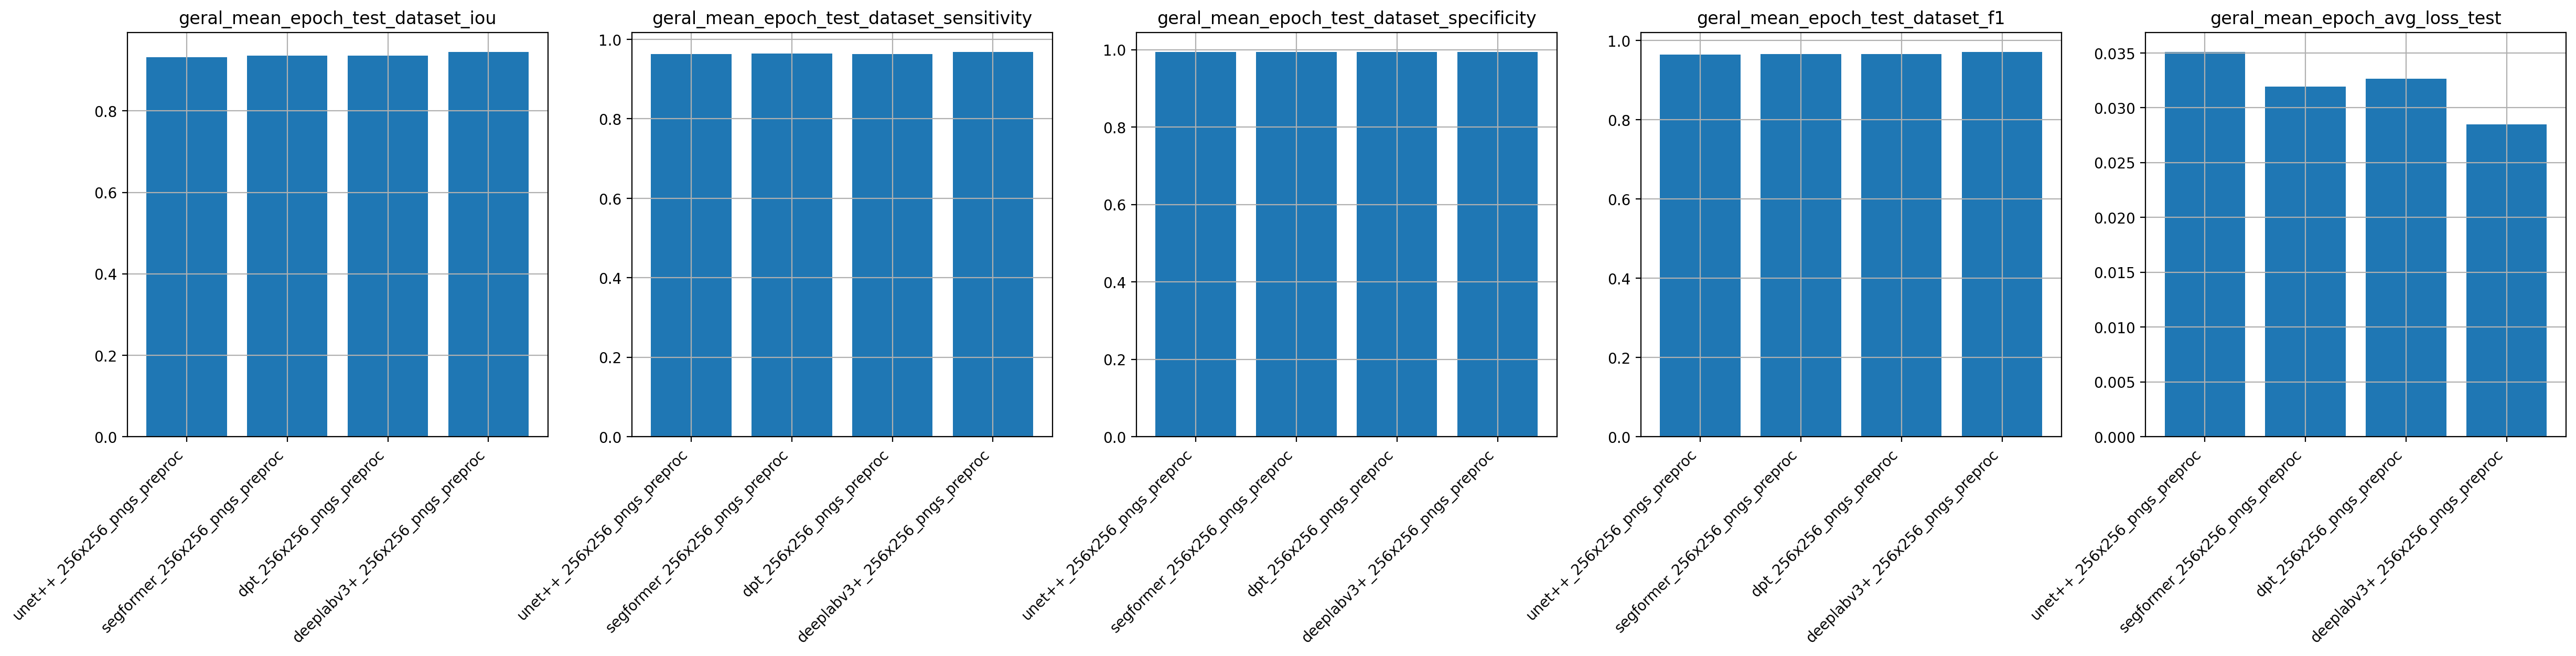

In [178]:
fig, axes = plt.subplots(1, 5, figsize=(30, 5), dpi=200)
# fig.subplots_adjust(hspace=0.5, wspace=0.3)

target_cols = [
    c for c in desempenho_medio_modelos.columns if 'image' not in c and c != 'model' # elimina métricas com redução 'per-image'
]

for i, ax in enumerate(axes.flat[:5]):  # Apenas os primeiros 5 subgráficos
    ax.bar(desempenho_medio_modelos['model'], desempenho_medio_modelos[target_cols[i]])  # Dados aleatórios para o gráfico
    ax.set_title(f"Gráfico {i+1}")

    ax.set_xticks(range(4))
    ax.set_xticklabels(desempenho_medio_modelos['model'], rotation=45, ha="right")
    ax.set_title(target_cols[i])
    ax.grid(True)

In [118]:
df_test

epoch_test_per_image_iou,epoch_test_dataset_iou,epoch_test_per_image_sensitivity,epoch_test_dataset_sensitivity,epoch_test_per_image_specificity,epoch_test_dataset_specificity,epoch_test_per_image_f1,epoch_test_dataset_f1,epoch_avg_loss_test,model,repet,kfolditer
f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32,i32
0.311821,0.964655,0.317192,0.978925,0.329266,0.994508,0.317538,0.981943,0.017907,"""deeplabv3+_256x256_pngs_prepro…",3,0
0.301495,0.95434,0.313993,0.975734,0.329262,0.995231,0.307346,0.976514,0.026368,"""deeplabv3+_256x256_pngs_prepro…",3,2
0.301112,0.938536,0.309229,0.962461,0.328781,0.993065,0.308547,0.968069,0.035667,"""deeplabv3+_256x256_pngs_prepro…",3,4
0.304892,0.950362,0.312934,0.96991,0.329072,0.993769,0.310918,0.974409,0.02665,"""deeplabv3+_256x256_pngs_prepro…",3,3
0.300347,0.916758,0.312397,0.954581,0.328989,0.993457,0.307038,0.956139,0.037651,"""deeplabv3+_256x256_pngs_prepro…",3,1
…,…,…,…,…,…,…,…,…,…,…,…
0.303163,0.946204,0.313347,0.97169,0.329404,0.994145,0.309885,0.972195,0.027134,"""segformer_256x256_pngs_preproc""",1,0
0.306526,0.949544,0.313097,0.967873,0.329099,0.99388,0.312414,0.973968,0.028361,"""segformer_256x256_pngs_preproc""",1,2
0.301483,0.94316,0.30778,0.962487,0.328274,0.992835,0.308741,0.97056,0.031077,"""segformer_256x256_pngs_preproc""",1,4


#### Shapiro-Wilk

In [31]:
df_test.columns

['epoch_test_per_image_iou',
 'epoch_test_dataset_iou',
 'epoch_test_per_image_sensitivity',
 'epoch_test_dataset_sensitivity',
 'epoch_test_per_image_specificity',
 'epoch_test_dataset_specificity',
 'epoch_test_per_image_f1',
 'epoch_test_dataset_f1',
 'epoch_avg_loss_test',
 'model',
 'repet',
 'kfolditer']

In [32]:
target_cols = [col for col in df_test.columns if 'epoch' in col and 'image' not in col]
target_cols

['epoch_test_dataset_iou',
 'epoch_test_dataset_sensitivity',
 'epoch_test_dataset_specificity',
 'epoch_test_dataset_f1',
 'epoch_avg_loss_test']

In [33]:
from scipy.stats import shapiro, friedmanchisquare

for metric in target_cols:
    print(f'================= {metric} =================')
    for model in df_test['model'].unique():
        print(model)
        df_filtrado = df_test.filter(pl.col('model') == model)
        stat, p_value = shapiro(df_filtrado[metric])

        result = f'Model: {model}\nStat: {stat}\nP-value: {p_value}\n'
        
        if p_value > 0.05:
            print(f'\033[32m{result}\033[0m')
            # print(result)
        else:
            print(result)

================= epoch_test_dataset_iou =================
segformer_256x256_pngs_preproc
Model: segformer_256x256_pngs_preproc
Stat: 0.8161164240712921
P-value: 0.005963807567941523

unet++_256x256_pngs_preproc
Model: unet++_256x256_pngs_preproc
Stat: 0.7399337220585496
P-value: 0.0006875206758899465

dpt_256x256_pngs_preproc
Model: dpt_256x256_pngs_preproc
Stat: 0.9154135002555275
P-value: 0.16391687372342817

deeplabv3+_256x256_pngs_preproc
Model: deeplabv3+_256x256_pngs_preproc
Stat: 0.8158928087487801
P-value: 0.005923280000102555

================= epoch_test_dataset_sensitivity =================
segformer_256x256_pngs_preproc
Model: segformer_256x256_pngs_preproc
Stat: 0.8431073663545035
P-value: 0.013891899542058847

unet++_256x256_pngs_preproc
Model: unet++_256x256_pngs_preproc
Stat: 0.70694477307691
P-value: 0.0002951489604400812

deeplabv3+_256x256_pngs_preproc
Model: deeplabv3+_256x256_pngs_preproc
Stat: 0.8230348122175094
P-value: 0.0073755731279936095

dpt_256x256_pngs_pr

#### Friedman

In [34]:
dados_teste_agrupados['epoch_test_dataset_iou', 'model']

data = {}
for model in df_test['model'].unique():
    data[model] = dados_teste_agrupados['epoch_test_dataset_iou', 'model'].filter(pl.col('model') == model)['epoch_test_dataset_iou'].to_numpy()[0]

In [35]:
df = pl.DataFrame(data)
df

segformer_256x256_pngs_preproc,dpt_256x256_pngs_preproc,unet++_256x256_pngs_preproc,deeplabv3+_256x256_pngs_preproc
f64,f64,f64,f64
0.934207,0.916704,0.92971,0.965577
0.953567,0.955536,0.952504,0.903507
0.94294,0.957668,0.961311,0.952203
0.906868,0.936814,0.917849,0.955878
0.965963,0.923033,0.938742,0.942099
…,…,…,…
0.879329,0.948659,0.946451,0.848461
0.954777,0.948888,0.894174,0.912025
0.938852,0.923959,0.902831,0.967411


In [36]:
for metric in target_cols:
    print(f'================= {metric} =================')
    dados_teste_agrupados[metric, 'model']

    data = {}
    for model in df_test['model'].unique():
        data[model] = (
            dados_teste_agrupados[metric, 'model']
            .filter(pl.col('model') == model)[metric]
            .to_numpy()[0]
        )
    print(data)


    stat, p_value = friedmanchisquare(
        data['deeplabv3+_256x256_pngs_preproc'].astype(np.float32),
        data['dpt_256x256_pngs_preproc'].astype(np.float32),
        data['segformer_256x256_pngs_preproc'].astype(np.float32),
        data['unet++_256x256_pngs_preproc'].astype(np.float32))


    result = f'RESULTADO (Friedman):\n\nStat: {stat}\nP-value: {p_value}\n'

    if p_value > 0.05:
        print(f'\033[32m{result}\033[0m')
        # print(result)
    else:
        print(result)

================= epoch_test_dataset_iou =================
{'deeplabv3+_256x256_pngs_preproc': array([0.96557665, 0.90350664, 0.95220315, 0.95587838, 0.94209945,
       0.96477675, 0.90576613, 0.95959032, 0.92075813, 0.95017552,
       0.84846127, 0.91202521, 0.96741056, 0.95676762, 0.95275652]), 'unet++_256x256_pngs_preproc': array([0.92971015, 0.95250416, 0.96131134, 0.91784859, 0.93874156,
       0.94582325, 0.91489208, 0.96528345, 0.74979097, 0.87461072,
       0.94645095, 0.8941735 , 0.90283149, 0.96668553, 0.94531697]), 'segformer_256x256_pngs_preproc': array([0.93420744, 0.95356667, 0.94294   , 0.90686774, 0.96596313,
       0.95193058, 0.93889105, 0.95437837, 0.89673316, 0.95189893,
       0.8793292 , 0.95477736, 0.93885231, 0.94500697, 0.95260572]), 'dpt_256x256_pngs_preproc': array([0.91670394, 0.95553637, 0.95766807, 0.93681377, 0.92303336,
       0.95768869, 0.9186179 , 0.91134483, 0.94616282, 0.91895646,
       0.94865942, 0.94888836, 0.92395949, 0.94280821, 0.96503198])}


### Diferenças entre modelos

In [33]:
# import scikit_posthocs as sp
# import pandas as pd

# df = pd.DataFrame(data)

# sp.posthoc_nemenyi_friedman(df)